## Review and edit state

Sometimes you want to let a human review and edit part of the graph state before continuing. This is useful for correcting LLMs, adding missing information, or making adjustments.

In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

# --- 1. Define the State for the New Domain (Financial) ---
class ExpenseState(TypedDict):
    """The state holds the expense details and its status."""
    employee_id: str
    amount: float
    justification: str
    status: str
    
# --- 2. Define Workflow Nodes ---

def draft_expense_node(state: ExpenseState):
    """Node 1: AI drafts an initial justification based on a transaction."""
    # Simulating an LLM reading a receipt and drafting a justification
    initial_justification = f"Draft: Lunch with client for Q3 strategy review. Amount seems high for a single meal."
    
    return {
        "employee_id": state.get("employee_id", "E1001"),
        "amount": state.get("amount", 150.00), # Assume initial amount is extracted
        "justification": initial_justification,
        "status": "DRAFTED"
    }

def manager_review_node(state: ExpenseState):
    """Node 2: Pause for Human-in-the-Loop review and editing."""
    
    # The interrupt call pauses and presents the current data to the human reviewer
    # It will return the human-edited dictionary when resumed
    edited_data = interrupt({
        "instruction": "Manager review required: Please verify the expense amount and justification. You can modify 'amount' and 'justification'.",
        "current_amount": state["amount"],
        "current_justification": state["justification"]
    })

    # When the graph resumes, 'edited_data' will contain the human's input.
    # We update the state with the human-provided values.
    return {
        "amount": float(edited_data.get("current_amount", state["amount"])), # Ensure amount is cast back to float
        "justification": edited_data.get("current_justification", state["justification"]),
        "status": "REVIEWED"
    }

def process_payment_node(state: ExpenseState):
    """Node 3: Final step to process the approved expense."""
    print("--- EXPENSE FINALIZED ---")
    print(f"Employee: {state['employee_id']}")
    print(f"Final Approved Amount: ${state['amount']:.2f}")
    print(f"Final Justification: {state['justification']}")
    print("STATUS: Payment Processing Initiated.")
    
    return {"status": "PAID"}

# --- 3. Build and Compile Graph ---
builder = StateGraph(ExpenseState)

builder.add_node("draft_expense", draft_expense_node)
builder.add_node("manager_review", manager_review_node)
builder.add_node("process_payment", process_payment_node)

builder.add_edge(START, "draft_expense")
builder.add_edge("draft_expense", "manager_review")
builder.add_edge("manager_review", "process_payment")
builder.add_edge("process_payment", END)

# Compile the graph
expense_graph = builder.compile(checkpointer=MemorySaver())

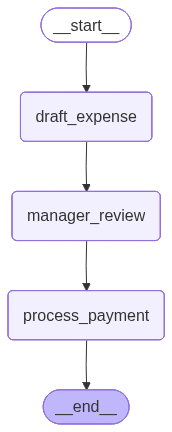

In [2]:
builder.compile(checkpointer=MemorySaver())

In [3]:
# --- 1. Initial Invoke (Will pause at the 'manager_review' node) ---
config = {"configurable": {"thread_id": "expense-002"}}

# Start the workflow with minimal initial data
initial = expense_graph.invoke({"employee_id": "M303", "amount": 250.00}, config=config)

print("--- Initial Run Output (Paused) ---")
print("Status:", initial.get("status"))
print("Interrupt Payload (What the human sees):")
# The interrupt payload contains the data the human needs to review/edit
print(initial.get("__interrupt__"))
print("-" * 30)




--- Initial Run Output (Paused) ---
Status: DRAFTED
Interrupt Payload (What the human sees):
[Interrupt(value={'instruction': "Manager review required: Please verify the expense amount and justification. You can modify 'amount' and 'justification'.", 'current_amount': 250.0, 'current_justification': 'Draft: Lunch with client for Q3 strategy review. Amount seems high for a single meal.'}, id='c2c7326b229660afc94856d5b0297cb7')]
------------------------------


In [4]:
# --- 2. Resume with Human-Edited Data ---
# The manager decides the amount was too high and edits the justification.
human_edits = {
    "current_amount": 125.00,  # Manager changes the amount
    "current_justification": "Approved: Lunch with two clients for Q3 strategy review. Itemized receipt attached."
}

# The Command(resume=...) is passed the dictionary of human edits
resumed = expense_graph.invoke(Command(resume=human_edits), config=config)

print("--- Resumed Run Output (Finished) ---")
print("Status:", resumed.get("status"))
print("Final State Report (showing the printed output from process_payment_node):")
print(f"Final Amount in State: ${resumed['amount']:.2f}")
print(f"Final Justification in State: {resumed['justification']}")
print("-" * 30)

--- EXPENSE FINALIZED ---
Employee: M303
Final Approved Amount: $125.00
Final Justification: Approved: Lunch with two clients for Q3 strategy review. Itemized receipt attached.
STATUS: Payment Processing Initiated.
--- Resumed Run Output (Finished) ---
Status: PAID
Final State Report (showing the printed output from process_payment_node):
Final Amount in State: $125.00
Final Justification in State: Approved: Lunch with two clients for Q3 strategy review. Itemized receipt attached.
------------------------------
